In [1]:
import numpy as np
from scipy.optimize import minimize
from IPython.display import clear_output
import time
from tqdm import tqdm
import matplotlib.pyplot as plt

rc = {"font.family" : "Times New Roman", 
      "mathtext.fontset" : "stix"}
plt.rcParams.update(rc)

from QAOA import *
from hamiltonians import *
from heuristics import *
from visualization import *
from analysis import *

import warnings
warnings.filterwarnings("ignore")

### Statistical evaluation for the fixed depth $p=n$

In [2]:
n = 6
n_instances = 100
path = 'data/cycle4/'+str(n)+'q/'
fname = str(n)+'q_nsk_'
avg_success, avg_iterations, avg_time, i_bad, nfev_stats = get_trained_stats(path,fname,n_instances)
    
print(f"Stats for {n} qubits Sherrington-Kirpatrick model:")
print(f"Avg success rate: {avg_success}")
print(f"Avg iterations: {avg_iterations}")
print(f"Avg time: {avg_time} s")    
print(f"Nfev stats: {np.mean(nfev_stats)}")  
print(i_bad)

Stats for 6 qubits Sherrington-Kirpatrick model:
Avg success rate: 1.0
Avg iterations: 4.3
Avg time: 3.314969809999999 s
Nfev stats: 2082.91
[]


### Number of cost function evaluations

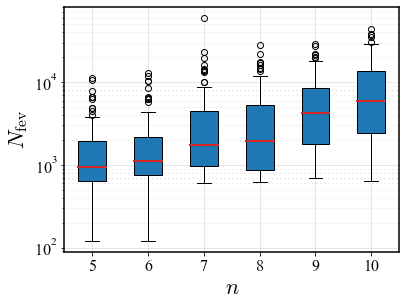

In [5]:
n_start = 5
n_end = 10
n_instances = 100



ns = np.array(range(n_start,n_end+1))
success = np.zeros(len(ns))
ar_data = np.zeros(len(ns))
nfevs = np.zeros((n_instances,len(ns)))
labels = []


for i in range(len(ns)):
    
    path = 'data/cycle1/'+str(ns[i])+'q/'
    fname = str(ns[i])+'q_nsk_'
    
    avg_success, avg_iterations, avg_time, i_bad, nfev_stats = get_trained_stats(path,fname,n_instances)
    
    nfevs[:,i] = nfev_stats

plot_nfev(nfevs,ns)

In [9]:
n_start = 5
n_end = 10
n_instances = 100



ns = np.array(range(n_start,n_end+1))
success = np.zeros(len(ns))
ar_data = np.zeros(len(ns))
nfev_lst = []
nfev_rscl_lst = []
nfev_vqa_lst = []
labels = []


for i in range(len(ns)):
    
    path = 'data/cycle1/'+str(ns[i])+'q/'
    fname = str(ns[i])+'q_nsk_'
    
    avg_success, avg_iterations, avg_time, i_bad, nfev_stats = get_trained_stats(path,fname,n_instances)
    nfev_lst.append(nfev_stats[0])
    
    path = 'data/cycle1/'+str(ns[i])+'q/'
    fname = str(ns[i])+'q_ev_'
    
    avg_success, avg_ar, nfev_rscl, avg_nfev, std_nfev, violated_A, i_bad = get_evaluation_stats(path,fname,n_instances,eps=0.5)
    nfev_rscl_lst.append(nfev_rscl)
    nfev_vqa_lst.append(avg_nfev)
    

print(nfev_lst)
print(np.mean(nfev_rscl_lst,axis=1))
print(nfev_vqa_lst)


[648.0, 764.0, 3012.0, 785.0, 5562.0, 6883.0]
[5140. 4592. 5120. 4956. 4540. 4544.]
[29319.05, 44090.79, 73373.49, 113658.42, 156995.73, 217381.61]


In [10]:
n = 6
n_instances = 100
path = 'data/cycle4/'+str(n)+'q/'
fname = str(n)+'q_ev_'

avg_success, avg_ar, nfev_rscl, avg_nfev, std_nfev, violated_A, i_bad = get_evaluation_stats(path,fname,n_instances,eps=0.5)

print(f"Evaluation stats for {n} qubits Sherrington-Kirpatrick model:")
print(f"Avg success rate: {avg_success}")
print(f"Avg approximation ratio: {avg_ar}")
print(f"Avg nfev rescaling: {np.mean(nfev_rscl)}")
print(f"Avg nfev: {avg_nfev}")
print(f"Std nfev: {std_nfev}")
print(f"Violated configurations: {violated_A}")
print(i_bad)

Evaluation stats for 6 qubits Sherrington-Kirpatrick model:
Avg success rate: 0.93
Avg approximation ratio: 0.9886848499973397
Avg nfev rescaling: 4736.0
Avg nfev: 44986.85
Std nfev: 9687.926087016765
Violated configurations: 0
[9, 24, 87, 90, 91, 97, 99]


[0.75 0.71 0.74 0.7  0.64 0.73]
[0.94 0.93 0.93 0.9  0.89 0.9 ]


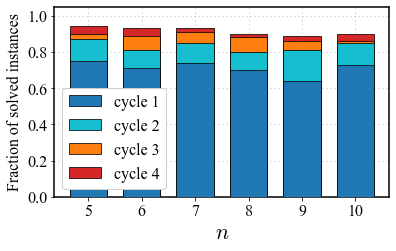

In [11]:
n_start = 5
n_end = 10
n_instances = 100


ns = np.array(range(n_start,n_end+1))
success = np.zeros(len(ns))
ar_data = np.zeros(len(ns))
success_lst = []
labels = []

for k in range(4):

    for i in range(len(ns)):
        path = f'data/cycle{k+1}/'+str(ns[i])+'q/'
        fname = str(ns[i])+'q_ev_'
        
        success[i], ar_data[i], nfev_rscl, avg_nfev, std_nfev, violated_A, i_bad = get_evaluation_stats(path,fname,n_instances,eps=0.5)
    success_lst.append(success.copy())
    labels.append(f'cycle {k+1}')  

print(success_lst[0])
print(success_lst[-1])

colors = ['tab:blue', 'tab:cyan', 'tab:orange', 'tab:red']
plot_bars_n(ns,success_lst,labels,colors)

## Statistical evaluation in the range of circuit depths up to $p=10$ layers

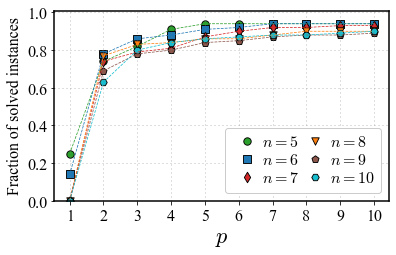

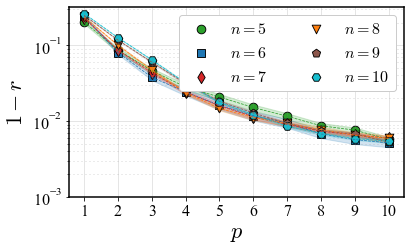

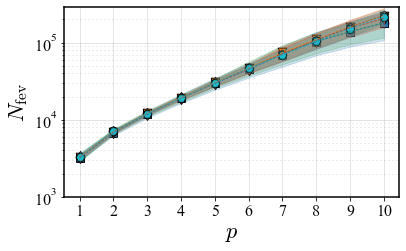

In [12]:
n_start = 5
n_end = 10
n_instances = 100
p_max = 10

data_frac_lst = []
data_r_lst = []
data_ovlp_lst = []
data_nfev_lst = []
labels = []

ns = np.array(range(n_start,n_end+1))
pp = np.array(range(1,p_max+1))  

for i in range(len(ns)):
    
    path = 'data/cycle4/'+str(ns[i])+'q/'
    fname = str(ns[i])+'q_lw_'
    
    avg_r, std_r, avg_ovlp, std_ovlp, avg_nfev, std_nfev, frac_solved, i_bad = get_lw_stats(path,fname,p_max,n_instances,eps=0.5)
    data_frac_lst.append(frac_solved)
    labels.append(f"$n={ns[i]}$")
    
    data_r = np.zeros((p_max,3))
    data_r[:,0] = pp
    data_r[:,1] = avg_r
    data_r[:,2] = std_r**2
    data_r_lst.append(data_r)
    
    data_nfev = np.zeros((p_max,3))
    data_nfev[:,0] = pp
    data_nfev[:,1] = avg_nfev
    data_nfev[:,2] = std_nfev
    data_nfev_lst.append(data_nfev)

markers = ['o', 's', 'd', 'v', 'p', 'H']
colors = ['tab:green', 'tab:blue', 'tab:red', 'tab:orange', 'tab:brown', 'tab:cyan']

plot_frac_solved(pp,data_frac_lst,labels,markers,colors)
plot_energies_log_avg(data_r_lst,labels,markers,colors,1e-3)
plot_avg_data(data_nfev_lst,labels,markers,colors,ylabel='$N_{\mathrm{fev}}$',ymin=1e3)

### Performance comparison to standard QAOA

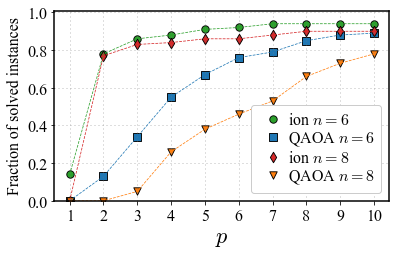

In [14]:
n_instances = 100
p_max = 10


data_frac_lst = []
labels = []

pp = np.array(range(1,p_max+1))  


for n in [6,8]:

    path = 'data/cycle4/'+str(n)+'q/'
    fname = str(n)+'q_lw_'
    
    avg_r, std_r, avg_ovlp, std_ovlp, avg_nfev, std_nfev, frac_solved, i_bad = get_lw_stats(path,fname,p_max,n_instances)
    data_frac_lst.append(frac_solved)
    labels.append(f"ion $n={n}$")

    path = 'data_qaoa/'+str(n)+'q/'
    fname = str(n)+'q_qaoa_'
    
    avg_r, std_r, avg_ovlp, std_ovlp, avg_nfev, std_nfev, frac_solved, i_bad = get_lw_stats(path,fname,p_max,n_instances,s=1)
    data_frac_lst.append(frac_solved)   
    labels.append(f"QAOA $n={n}$")

markers = ['o', 's', 'd', 'v', 'p', 'H']
colors = ['tab:green', 'tab:blue', 'tab:red', 'tab:orange', 'tab:brown', 'tab:cyan']

plot_frac_solved(pp,data_frac_lst,labels,markers,colors,ncol=1)

